# Exploratory Data Analysis - Telco Customer Churn

This notebook explores the cleaned Telco Customer Churn dataset created in Phase 03. The goal is to understand churn distribution, customer behavior patterns, and business signals before model preprocessing or training.

No modeling is performed in this notebook.

## 1. Setup

Load the cleaned dataset and configure plotting. The notebook expects the local processed CSV to exist at `data/processed/telco_customer_churn_cleaned.csv`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "telco_customer_churn_cleaned.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('C:/Users/simon/Documents/Proyectos markdow/customer-churn-prediction-model/data/processed/telco_customer_churn_cleaned.csv')

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2. Data Quality Snapshot

Confirm that Phase 03 produced a clean analysis-ready dataset with no missing values, numeric `TotalCharges`, and binary `Churn`.

In [3]:
quality_summary = {
    "rows": len(df),
    "columns": len(df.columns),
    "missing_values_total": int(df.isna().sum().sum()),
    "total_charges_dtype": str(df["TotalCharges"].dtype),
    "churn_values": sorted(df["Churn"].unique().tolist()),
}
quality_summary

{'rows': 7043,
 'columns': 21,
 'missing_values_total': 0,
 'total_charges_dtype': 'float64',
 'churn_values': [0, 1]}

## 3. Target Distribution

Analyze the class balance of `Churn`. This matters because churn is often a minority class, and later model evaluation should not rely on accuracy alone.

In [4]:
churn_counts = df["Churn"].value_counts().sort_index()
churn_rate = df["Churn"].mean()

churn_summary = pd.DataFrame({
    "label": ["No churn", "Churn"],
    "count": [churn_counts.get(0, 0), churn_counts.get(1, 0)],
    "rate": [1 - churn_rate, churn_rate],
})
churn_summary

,label,count,rate
0,No churn,5174,0.73463
1,Churn,1869,0.26537


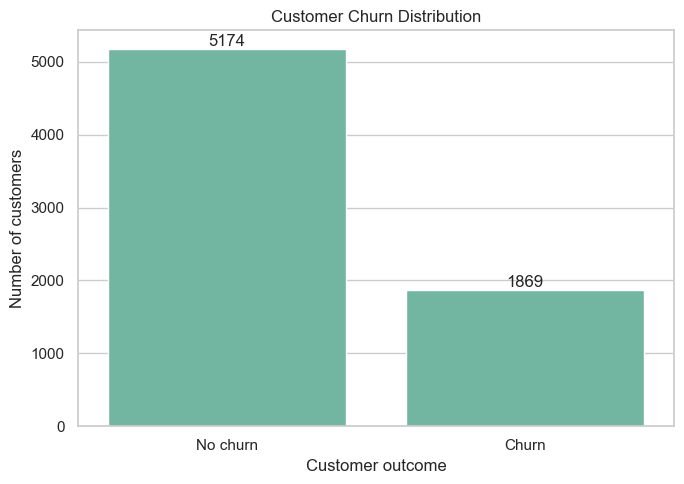

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=churn_summary, x="label", y="count", ax=ax)
ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Customer outcome")
ax.set_ylabel("Number of customers")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "churn_distribution.png", dpi=150)
plt.show()

**Insight:** Around one quarter of customers churned. This indicates a meaningful minority class, so later evaluation should prioritize recall, precision, F1-score, ROC-AUC, and confusion matrix, not accuracy alone.

## 4. Numerical Variables

Compare `tenure`, `MonthlyCharges`, and `TotalCharges` between customers who churned and customers who stayed.

In [6]:
numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
num_summary = df.groupby("Churn")[numeric_columns].agg(["mean", "median", "std"]).round(2)
num_summary

tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
0      37.57   38.0  24.11          61.27  64.43  31.09      2549.91  1679.52   
1      17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
0      2329.95  
1      1890.82

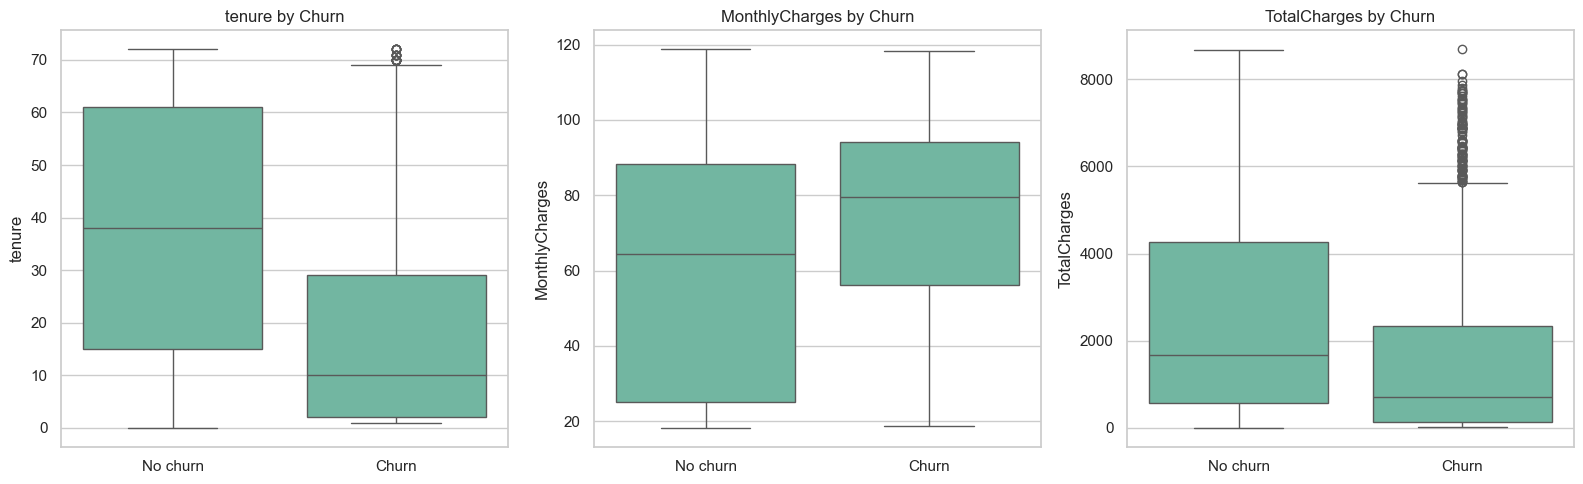

In [7]:
plot_data = df.copy()
plot_data["ChurnLabel"] = plot_data["Churn"].map({0: "No churn", 1: "Churn"})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(data=plot_data, x="ChurnLabel", y=column, ax=ax)
    ax.set_title(f"{column} by Churn")
    ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "numeric_variables_by_churn.png", dpi=150)
plt.show()

**Insight:** Churned customers have much lower average tenure but higher monthly charges. Total charges are lower for churned customers mainly because many leave earlier in the customer lifecycle.

## 5. Tenure-Related Churn Patterns

Group tenure into interpretable customer lifecycle bands to see how churn changes as customers stay longer.

In [8]:
tenure_bins = [-1, 12, 24, 48, 72]
tenure_labels = ["0-12", "13-24", "25-48", "49-72"]
df["tenure_group"] = pd.cut(df["tenure"], bins=tenure_bins, labels=tenure_labels)

tenure_churn = (
    df.groupby("tenure_group", observed=True)["Churn"]
    .agg(customers="count", churn_rate="mean")
    .reset_index()
)
tenure_churn["churn_rate"] = tenure_churn["churn_rate"].round(4)
tenure_churn

,tenure_group,customers,churn_rate
0,0-12,2186,0.4744
1,13-24,1024,0.2871
2,25-48,1594,0.2039
3,49-72,2239,0.0951


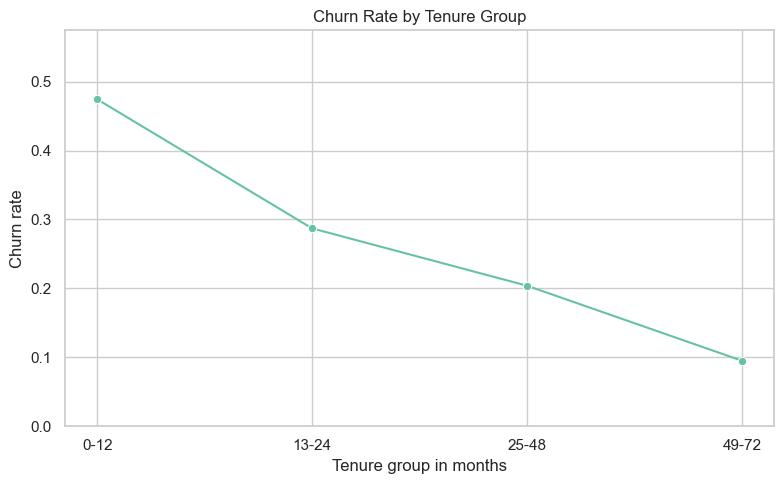

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=tenure_churn, x="tenure_group", y="churn_rate", marker="o", ax=ax)
ax.set_title("Churn Rate by Tenure Group")
ax.set_xlabel("Tenure group in months")
ax.set_ylabel("Churn rate")
ax.set_ylim(0, max(tenure_churn["churn_rate"]) + 0.1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tenure_group_churn_rate.png", dpi=150)
plt.show()

**Insight:** Churn is highest during the first year and declines as tenure increases. Early lifecycle retention is likely a key business opportunity.

## 6. Categorical Variables

Review churn rate across important customer, service, and billing segments.

In [10]:
categorical_columns = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
]

def churn_rate_by_category(data: pd.DataFrame, column: str) -> pd.DataFrame:
    result = (
        data.groupby(column)["Churn"]
        .agg(customers="count", churn_rate="mean")
        .sort_values("churn_rate", ascending=False)
        .reset_index()
    )
    result["feature"] = column
    return result[["feature", column, "customers", "churn_rate"]]

category_summaries = {column: churn_rate_by_category(df, column) for column in categorical_columns}
category_summaries["Contract"]

,feature,Contract,customers,churn_rate
0,Contract,Month-to-month,3875,0.427097
1,Contract,One year,1473,0.112695
2,Contract,Two year,1695,0.028319


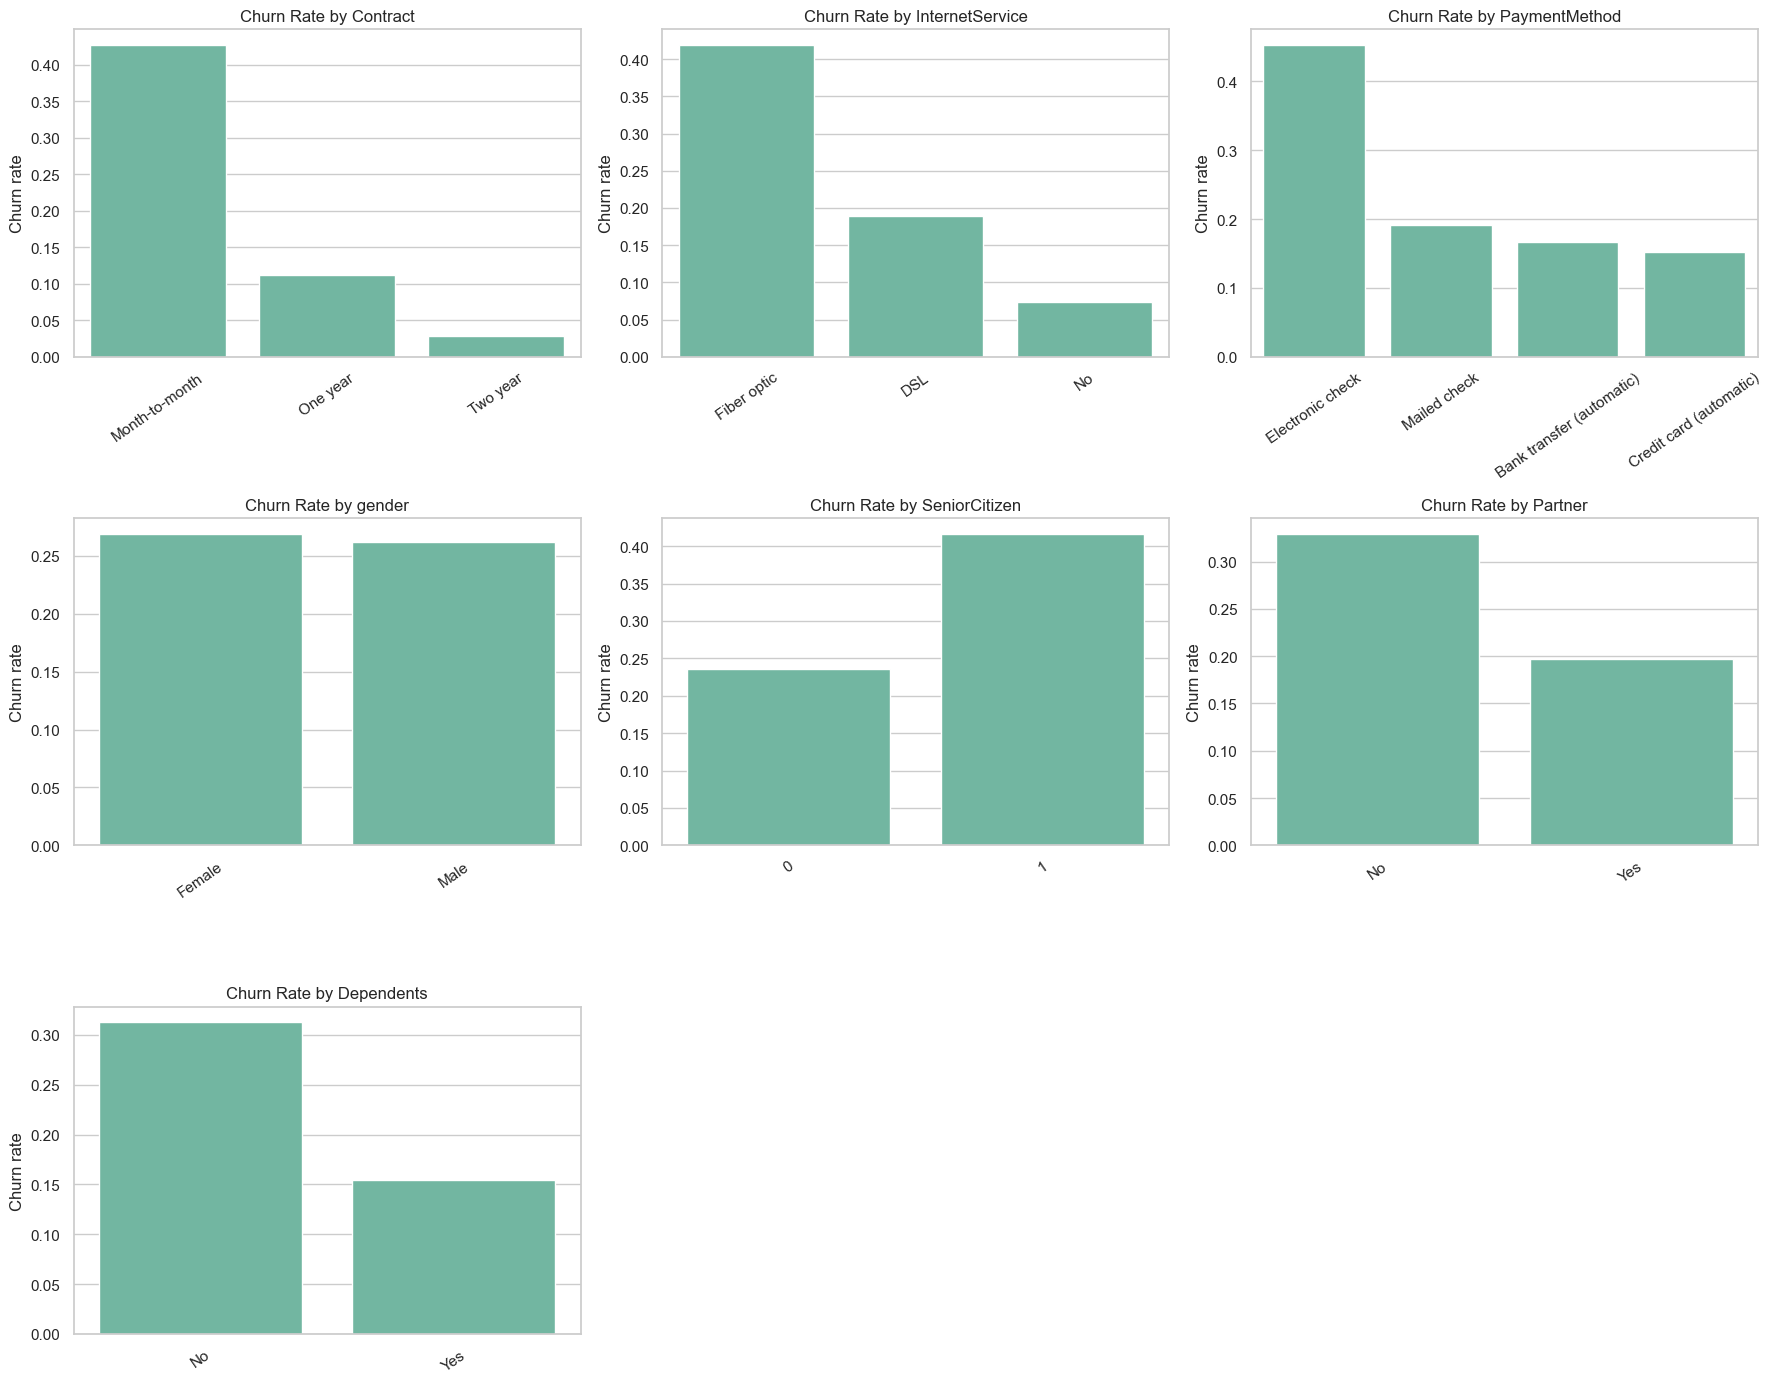

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    summary = churn_rate_by_category(df, column)
    sns.barplot(data=summary, x=column, y="churn_rate", ax=ax)
    ax.set_title(f"Churn Rate by {column}")
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=35)

for ax in axes[len(categorical_columns):]:
    ax.axis("off")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "categorical_churn_rates.png", dpi=150)
plt.show()

**Insights:** Month-to-month contracts show much higher churn than one-year and two-year contracts. Fiber optic customers and electronic check customers also show elevated churn. Gender has little separation, while senior citizens, customers without partners, and customers without dependents have higher churn rates.

## 7. Business Takeaways

- The overall churn rate is high enough to justify retention analysis.
- The first 12 months are the highest-risk customer lifecycle period.
- Month-to-month contracts are a major churn risk segment.
- Fiber optic and electronic check segments deserve further investigation before modeling.
- Demographic variables may help, but contract, service, billing, and tenure patterns appear more directly actionable.

These findings should guide Phase 05 preprocessing and later feature selection, but no model training is performed here.